In [3]:
pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import scipy.stats as ss
from scipy.stats import chi2_contingency, chi2, kruskal, mannwhitneyu
import scikit_posthocs as sp
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

### Проверьте, есть ли различия в размерах оттока клиентов в разных городах (churn, city)

In [5]:
df = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_7/churn.csv')
df.head()

,avg_dist,avg_rating_by_driver,avg_rating_of_driver,avg_surge,city,last_trip_date,phone,signup_date,surge_pct,trips_in_first_30_days,luxury_car_user,weekday_pct
0,3.67,5.0,4.7,1.10,King's Landing,2014-06-17,iPhone,2014-01-25,15.4,4,True,46.2
1,8.26,5.0,5.0,1.00,Astapor,2014-05-05,Android,2014-01-29,0.0,0,False,50.0
2,0.77,5.0,4.3,1.00,Astapor,2014-01-07,iPhone,2014-01-06,0.0,3,False,100.0
3,2.36,4.9,4.6,1.14,King's Landing,2014-06-29,iPhone,2014-01-10,20.0,9,True,80.0
4,3.13,4.9,4.4,1.19,Winterfell,2014-03-15,Android,2014-01-27,11.8,14,False,82.4


In [6]:
df.last_trip_date = pd.to_datetime(df.last_trip_date)
df.signup_date = pd.to_datetime(df.signup_date)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   avg_dist                50000 non-null  float64       
 1   avg_rating_by_driver    49799 non-null  float64       
 2   avg_rating_of_driver    41878 non-null  float64       
 3   avg_surge               50000 non-null  float64       
 4   city                    50000 non-null  object        
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   49604 non-null  object        
 7   signup_date             50000 non-null  datetime64[ns]
 8   surge_pct               50000 non-null  float64       
 9   trips_in_first_30_days  50000 non-null  int64         
 10  luxury_car_user         50000 non-null  bool          
 11  weekday_pct             50000 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int

In [7]:
df['days_since_last_trip'] = df.last_trip_date.max() - df.last_trip_date
df['days_since_last_trip']

0        14 days
1        57 days
2       175 days
3         2 days
4       108 days
          ...   
49995    26 days
49996   157 days
49997    40 days
49998   167 days
49999    72 days
Name: days_since_last_trip, Length: 50000, dtype: timedelta64[ns]

In [8]:
df['days_since_last_trip'] = df['days_since_last_trip'].dt.days
df['days_since_last_trip']

0         14
1         57
2        175
3          2
4        108
        ... 
49995     26
49996    157
49997     40
49998    167
49999     72
Name: days_since_last_trip, Length: 50000, dtype: int64

In [9]:
df['churn'] = df.days_since_last_trip.apply(lambda x: 'churn' if x > 30 else 'not_churn')
df[['days_since_last_trip', 'churn']]

,days_since_last_trip,churn
0,14,not_churn
1,57,churn
2,175,churn
3,2,not_churn
4,108,churn
...,...,...
49995,26,not_churn
49996,157,churn
49997,40,churn
49998,167,churn


In [10]:
df.churn.value_counts(normalize=True).mul(100)

churn
churn        62.392
not_churn    37.608
Name: proportion, dtype: float64

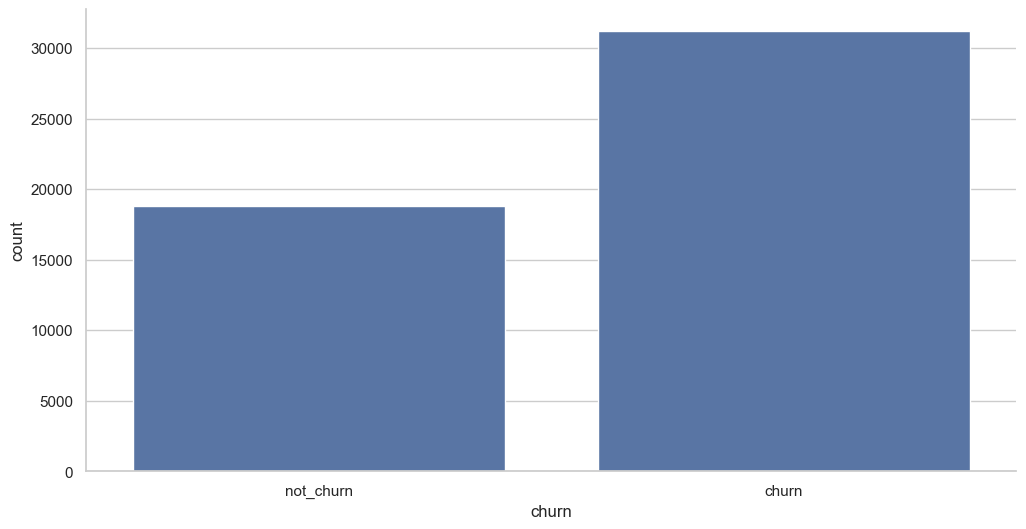

In [15]:
sns.set_theme(rc={'figure.figsize': (12, 6)}, style="whitegrid")
sns.countplot(x='churn', data=df)
sns.despine()
plt.show()

In [16]:
tab = pd.crosstab(df.churn, df.city)
print(tab)

city       Astapor  King's Landing  Winterfell
churn                                         
churn        12306            3767       15123
not_churn     4228            6363        8213


In [17]:
stat, p, dof, expected = chi2_contingency(tab)
print(p)

0.0


Для проверки этой гипотезы используем `ХИ-КВАДРАТ`, поскольку переменные: `ОБЕ КАТЕГОРИАЛЬНЫЕ`. Нулевая гипотеза `ОТКЛОНЯЕТСЯ`, поскольку `p-value < 0. 05`. Значит, `ВЗАИМОСВЯЗЬ ЕСТЬ`.



## Есть ли разница в активности в первые 30 дней с момента регистрации между водителями из разных городов? (city, trips_in_first_30_days)


In [18]:
import scipy
from scipy.stats import shapiro

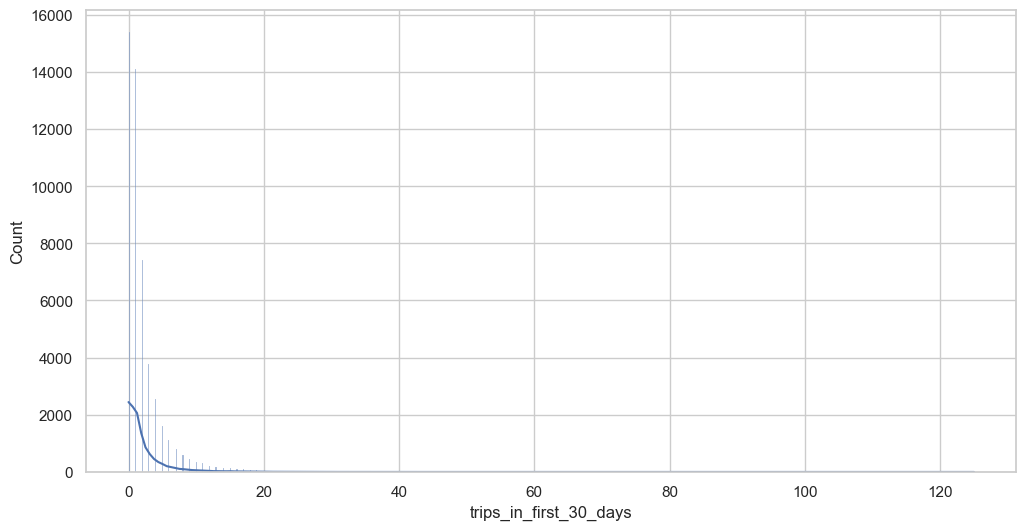

In [19]:
sns.set_theme(rc={'figure.figsize': (12, 6)}, style="whitegrid")
sns.despine()
sns.histplot(df.trips_in_first_30_days, kde=True)
plt.show()

In [20]:
ast = df[df.city == 'Astapor'].trips_in_first_30_days
king = df[df.city == "King's Landing"].trips_in_first_30_days
winter = df[df.city == 'Winterfell'].trips_in_first_30_days

In [21]:
print(shapiro(ast.sample(1000, random_state=17)))
print(shapiro(king.sample(1000, random_state=17)))
print(shapiro(winter.sample(1000, random_state=17)))

ShapiroResult(statistic=0.5414699844895436, pvalue=4.822611722650788e-45)
ShapiroResult(statistic=0.6132173383426862, pvalue=1.6834188295275776e-42)
ShapiroResult(statistic=0.5455789939910616, pvalue=6.602753909260042e-45)


Распределения не являются нормальными, поэтому используем непараметрический аналог ANOVA – критерий Краскела-Уоллиса

## Есть ли разница в активности в первые 30 дней с момента регистрации между водителями из разных городов? (city, trips_in_first_30_days)

In [22]:
kr_res = kruskal(ast, king, winter)
print(kr_res)

KruskalResult(statistic=221.32105325317454, pvalue=8.724567791938856e-49)


Обнаружены статистически значимые различия.

## Может ли отток быть связан с активностью в первые 30 дней после регистрации? (churn, trips_in_first_30_days)

In [23]:
churn = df[df.churn == 'churn'].trips_in_first_30_days
not_churn = df[df.churn == 'not_churn'].trips_in_first_30_days

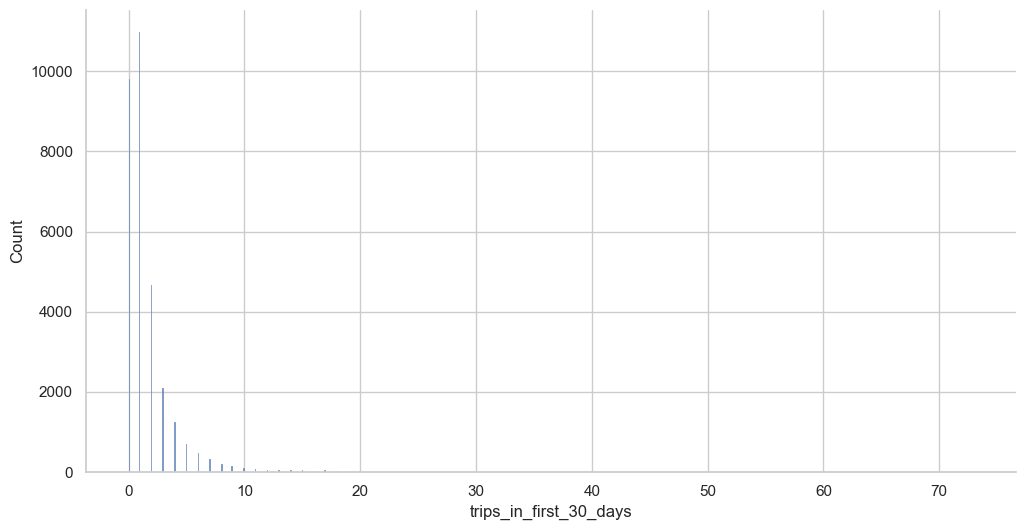

In [24]:
sns.histplot(churn)
sns.despine()

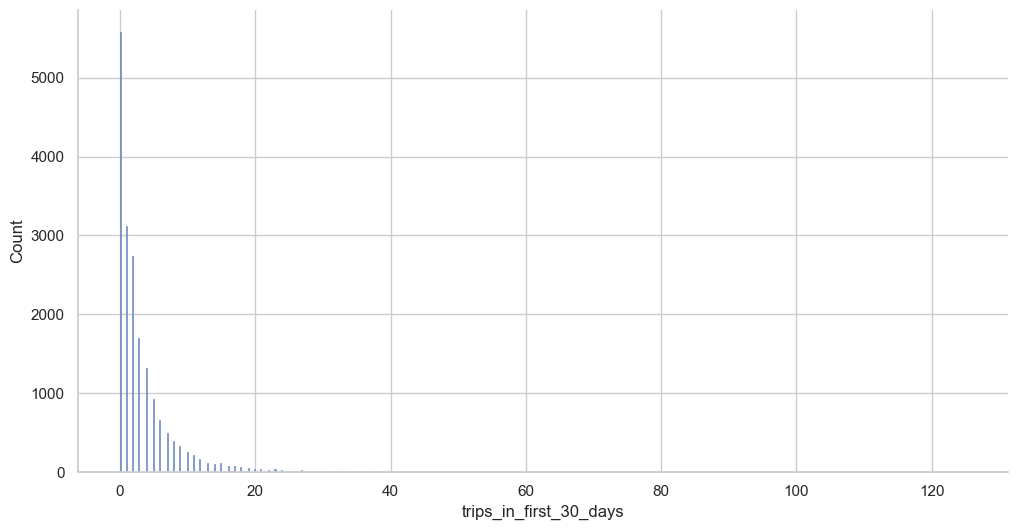

In [25]:
sns.histplot(not_churn)
sns.despine()

In [26]:
mannwhitneyu(churn, not_churn)

MannwhitneyuResult(statistic=234767452.0, pvalue=0.0)

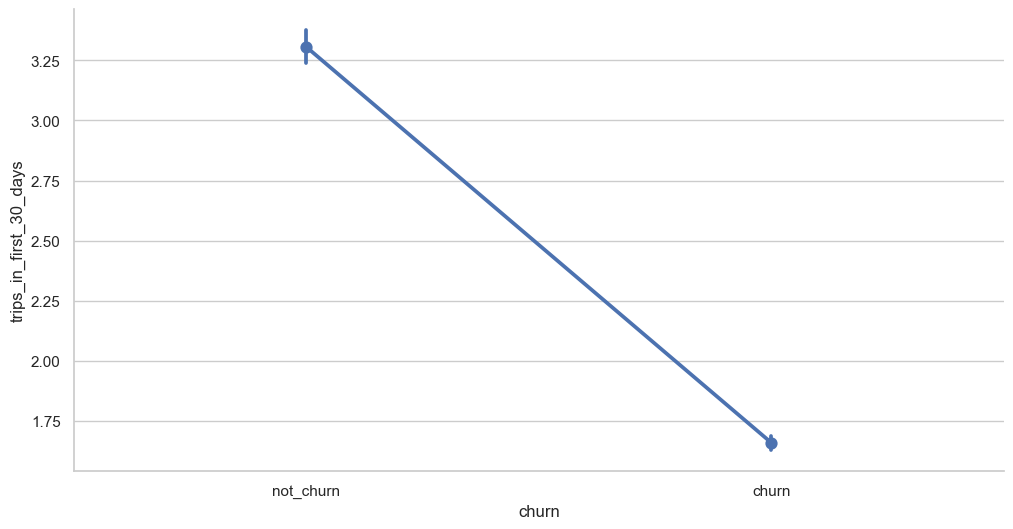

In [27]:
sns.pointplot(x='churn', y='trips_in_first_30_days', data=df)
sns.despine()

Распределение переменной trips_in_first_30_days `НЕ ЯВЛЯЕТСЯ НОРМАЛЬНЫМ`, поэтому для проверки гипотезы используем `U-КРИТЕРИЙ МАННА-УИТНИ`. Результат оказался статистически `ЗНАЧИМ`. Значит, `ЗНАЧИМЫЕ РАЗЛИЧИЯ ЕСТЬ, УШЕДШИЕ ПОЛЬЗОВАТЕЛИ БЫЛИ МЕНЕЕ АКТИВНЫ`.